# Walking data 

In [58]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np
from scipy import signal

In [59]:
gait_data = pd.read_csv('data_gait.csv')
gait_data

,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399
...,...,...,...,...,...,...,...
181795,10,3,10,2,3,96,29.778412
181796,10,3,10,2,3,97,29.247559
181797,10,3,10,2,3,98,28.796951
181798,10,3,10,2,3,99,28.432936


In [60]:
specific_data = gait_data[(gait_data["subject"]==1) & (gait_data["condition"]==1) & (gait_data["leg"]==1) & (gait_data["joint"]==1)]
specific_data

,subject,condition,replication,leg,joint,time,angle
0,1,1,1,1,1,0,4.682881
1,1,1,1,1,1,1,5.073127
2,1,1,1,1,1,2,5.229774
3,1,1,1,1,1,3,5.083273
4,1,1,1,1,1,4,4.652399
...,...,...,...,...,...,...,...
5550,1,1,10,1,1,96,2.892768
5551,1,1,10,1,1,97,2.937814
5552,1,1,10,1,1,98,3.345530
5553,1,1,10,1,1,99,3.967985


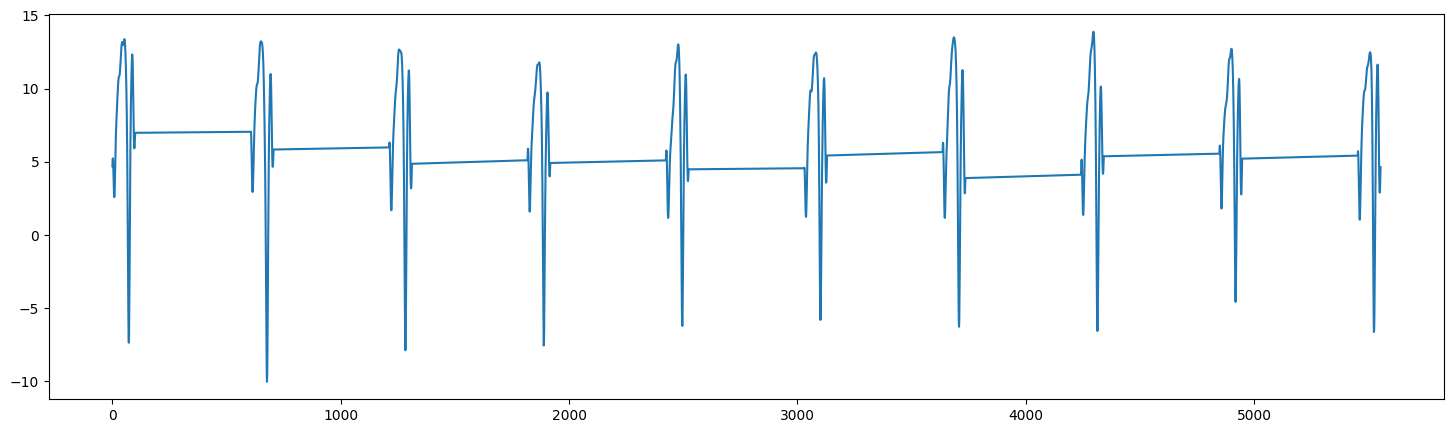

In [61]:
plt.figure(figsize=(18,5))
plt.plot(specific_data['angle'])
plt.show()

In [62]:
rng = np.random.default_rng(42)


In [63]:
specific_data["noised_series"] = specific_data["angle"]+rng.normal(loc=0.0, scale=1.0)
specific_data

/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_71864/4035221590.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  specific_data["noised_series"] = specific_data["angle"]+rng.normal(loc=0.0, scale=1.0)


,subject,condition,replication,leg,joint,time,angle,noised_series
0,1,1,1,1,1,0,4.682881,4.987598
1,1,1,1,1,1,1,5.073127,5.377844
2,1,1,1,1,1,2,5.229774,5.534491
3,1,1,1,1,1,3,5.083273,5.387990
4,1,1,1,1,1,4,4.652399,4.957116
...,...,...,...,...,...,...,...,...
5550,1,1,10,1,1,96,2.892768,3.197485
5551,1,1,10,1,1,97,2.937814,3.242531
5552,1,1,10,1,1,98,3.345530,3.650248
5553,1,1,10,1,1,99,3.967985,4.272702


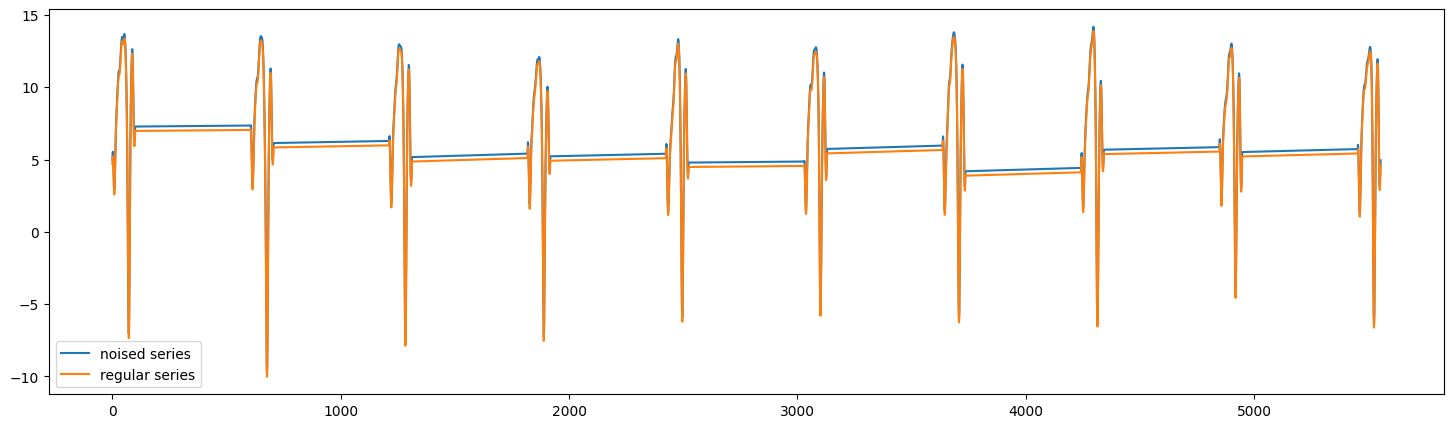

In [64]:
plt.figure(figsize=(18,5))
plt.plot(specific_data['noised_series'], label='noised series')
plt.plot(specific_data['angle'], label='regular series')
plt.legend()
plt.show()

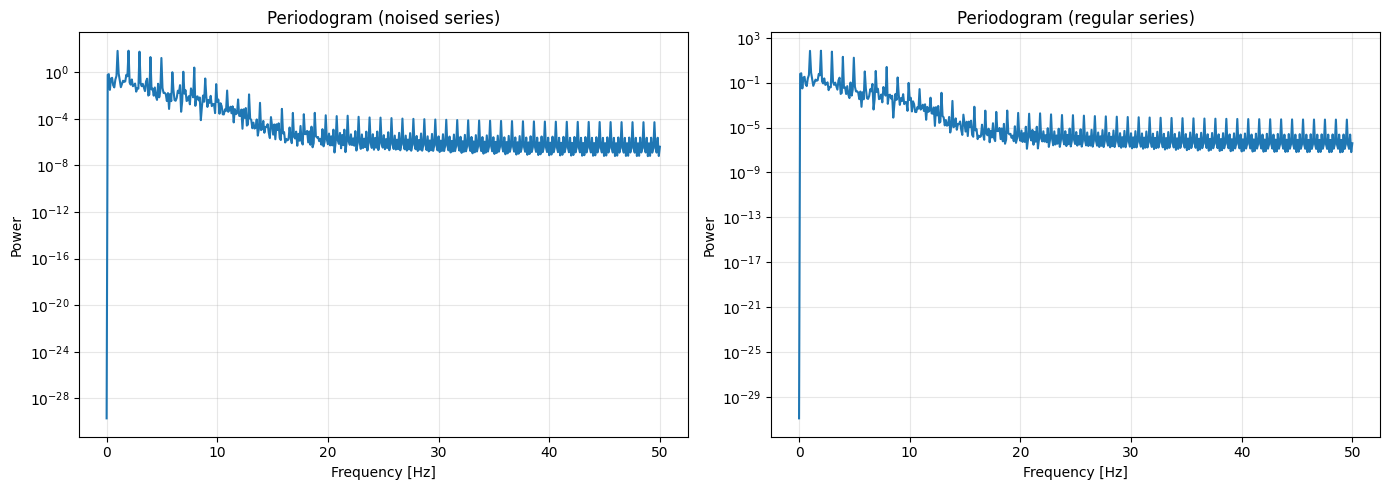

In [65]:
# Periodograms for both noised and regular series
noised_series = specific_data['noised_series'].values
regular_series = specific_data['angle'].values

# Sample rate (adjust if your data has a different sampling frequency)
fs = 100

f_noised, Pxx_noised = signal.periodogram(noised_series, fs=fs)
f_regular, Pxx_regular = signal.periodogram(regular_series, fs=fs)

plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.semilogy(f_noised, Pxx_noised)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title('Periodogram (noised series)')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.semilogy(f_regular, Pxx_regular)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title('Periodogram (regular series)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

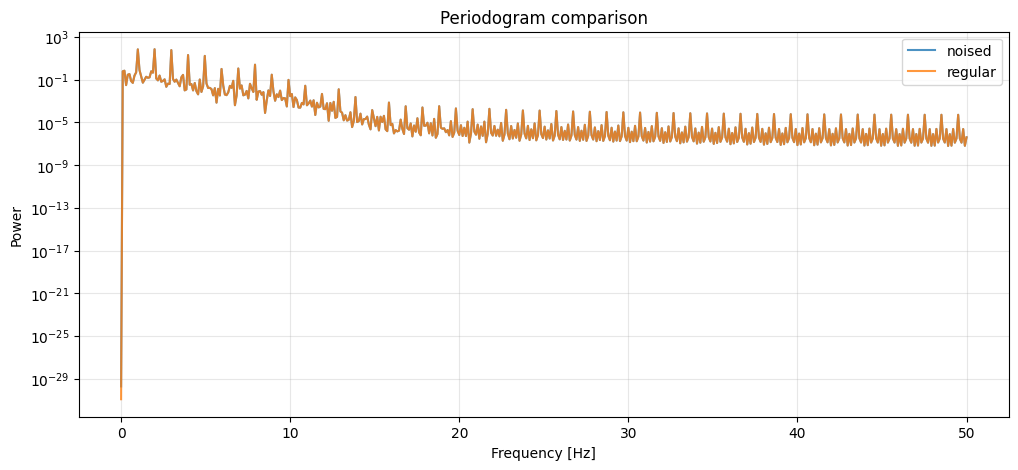

In [66]:
# Optional: Overlay both periodograms for comparison
plt.figure(figsize=(12, 5))
plt.semilogy(f_noised, Pxx_noised, label='noised', alpha=0.8)
plt.semilogy(f_regular, Pxx_regular, label='regular', alpha=0.8)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Power')
plt.title('Periodogram comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 1.5 De-noising via DFT Filtering

Three-step procedure: (1) DFT of noisy signal, (2) zero out mid-band frequencies (102 ≤ ω ≤ 899), (3) inverse DFT.

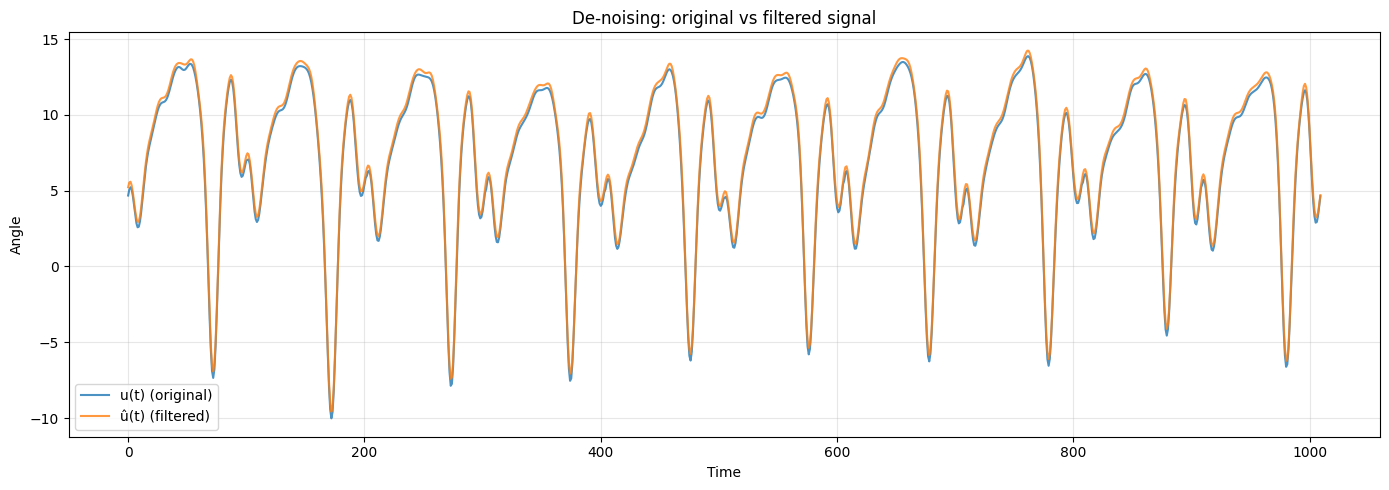

In [67]:
# Step 1: Compute DFT of noisy signal ũ(t) → Ũ_N(ω)
U_tilde = np.fft.fft(noised_series)
N = len(U_tilde)

# Step 2: Frequency-domain filter
# Keep Ũ_N(ω) if ω ≤ 101 or ω ≥ 900; zero otherwise (indices 102 to 899)
U_hat = U_tilde.copy()
U_hat[102:900] = 0  # zero out indices 102 through 899 (exclusive of 900)

# Step 3: Inverse DFT → û(t)
u_hat = np.fft.ifft(U_hat).real

# Plot u(t) vs û(t)
plt.figure(figsize=(14, 5))
plt.plot(regular_series, label='u(t) (original)', alpha=0.8)
plt.plot(u_hat, label='û(t) (filtered)', alpha=0.8)
plt.xlabel('Time')
plt.ylabel('Angle')
plt.title('De-noising: original vs filtered signal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1.6 Cosine Noise

Instead of white noise: **ε(t) = 2 cos(2πt / 202)** and **w̃(t) = u(t) + ε(t)**. Plot w̃ and u versus t.

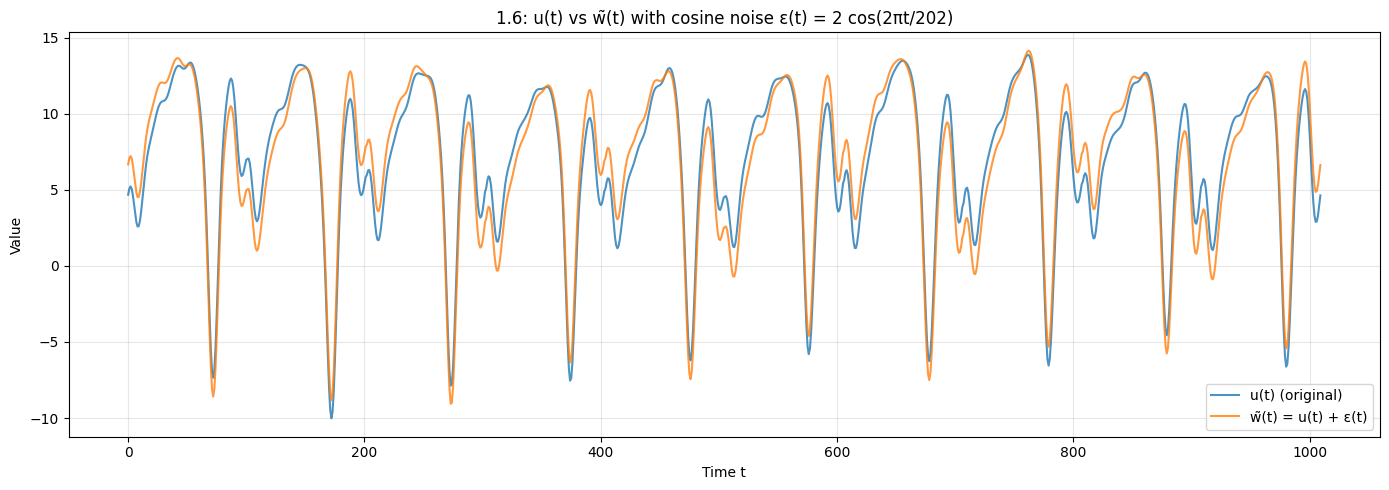

In [68]:
# ε(t) = 2 cos(2πt / 202), w̃(t) = u(t) + ε(t)
t = np.arange(len(regular_series))
epsilon = 2 * np.cos(2 * np.pi * t / 202)
w_tilde = regular_series + epsilon

plt.figure(figsize=(14, 5))
plt.plot(t, regular_series, label='u(t) (original)', alpha=0.8)
plt.plot(t, w_tilde, label='w̃(t) = u(t) + ε(t)', alpha=0.8)
plt.xlabel('Time t')
plt.ylabel('Value')
plt.title('1.6: u(t) vs w̃(t) with cosine noise ε(t) = 2 cos(2πt/202)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()